
# ANN for Breast Cancer Classification

## Experiment
To build an ANN model for a classification problem on the Breast Cancer dataset and study the effect of:
1. Early Stopping
2. Dropout



## Aim
Build and compare three ANN models:
- **Baseline ANN**
- **ANN with Early Stopping**
- **ANN with Dropout + Early Stopping**

## Expected Observation
- Early Stopping should reduce overfitting and stop training when validation loss stops improving.
- Dropout should improve generalization by randomly dropping neurons during training.


In [ ]:
#Architecture Details:

1. Input Layer:
   - Number of neurons = 30 (same as number of features)

2. Hidden Layer 1:
   - 32 neurons
   - Activation Function: ReLU

3. Hidden Layer 2:
   - 16 neurons
   - Activation Function: ReLU

4. Output Layer:
   - 1 neuron
   - Activation Function: Sigmoid (for binary classification)


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [2]:

# 1. Load dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Target classes:", cancer.target_names)


Feature matrix shape: (569, 30)
Target shape: (569,)
Target classes: ['malignant' 'benign']


In [3]:

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [4]:

# Helper function to build models

def build_baseline_model(input_dim):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_dim,)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


def build_dropout_model(input_dim):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [5]:

# Common callback for early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


In [6]:

# 4A. Baseline model (no early stopping, no dropout)
baseline_model = build_baseline_model(X_train.shape[1])

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.5440 - loss: 0.6814 - val_accuracy: 0.8132 - val_loss: 0.5838
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8681 - loss: 0.5413 - val_accuracy: 0.9011 - val_loss: 0.4790
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9313 - loss: 0.4426 - val_accuracy: 0.9560 - val_loss: 0.3985
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9451 - loss: 0.3638 - val_accuracy: 0.9670 - val_loss: 0.3298
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9505 - loss: 0.2971 - val_accuracy: 0.9670 - val_loss: 0.2726
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9533 - loss: 0.2411 - val_accuracy: 0.9670 - val_loss: 0.2249
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9560 - loss: 0.1976 - val_accuracy: 0.9670 - val_loss: 0.1887
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9643 - loss: 0.1666 - val_accuracy: 0.

In [7]:

# 4B. Model with Early Stopping
es_model = build_baseline_model(X_train.shape[1])

history_es = es_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6429 - loss: 0.6360 - val_accuracy: 0.8352 - val_loss: 0.5309
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8929 - loss: 0.4632 - val_accuracy: 0.9231 - val_loss: 0.4059
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9396 - loss: 0.3495 - val_accuracy: 0.9341 - val_loss: 0.3112
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9423 - loss: 0.2689 - val_accuracy: 0.9341 - val_loss: 0.2405
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9423 - loss: 0.2128 - val_accuracy: 0.9451 - val_loss: 0.1916
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9478 - loss: 0.1766 - val_accuracy: 0.9560 - val_loss: 0.1582
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9478 - loss: 0.1518 - val_accuracy: 0.9560 - val_loss: 0.1328
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9505 - loss: 0.1339 - val_accuracy: 0.9560 -

In [8]:

# 4C. Model with Dropout + Early Stopping
dropout_model = build_dropout_model(X_train.shape[1])

history_dropout = dropout_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.4066 - loss: 0.8300 - val_accuracy: 0.4505 - val_loss: 0.6479
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5577 - loss: 0.6573 - val_accuracy: 0.7363 - val_loss: 0.5116
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7473 - loss: 0.5417 - val_accuracy: 0.8901 - val_loss: 0.4197
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8407 - loss: 0.4460 - val_accuracy: 0.9560 - val_loss: 0.3490
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8819 - loss: 0.3704 - val_accuracy: 0.9560 - val_loss: 0.2873
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9011 - loss: 0.3346 - val_accuracy: 0.9670 - val_loss: 0.2365
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9258 - loss: 0.2740 - val_accuracy: 0.9670 - val_loss: 0.1953
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9313 - loss: 0.2327 - val_accuracy: 0.9670 -

In [9]:
def evaluate_model(model, X_test, y_test, name):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    y_prob = model.predict(X_test, verbose=0)
    y_pred = (y_prob > 0.5).astype(int)

    print(f"\n{name}")
    print("-" * len(name))
    print("Test Loss:", round(loss, 4))
    print("Test Accuracy:", round(acc, 4))
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

    return loss, acc

In [10]:

# 6. Evaluate all models
baseline_loss, baseline_acc = evaluate_model(baseline_model, X_test, y_test, "Baseline ANN")
es_loss, es_acc = evaluate_model(es_model, X_test, y_test, "ANN with Early Stopping")
drop_loss, drop_acc = evaluate_model(dropout_model, X_test, y_test, "ANN with Dropout + Early Stopping")



Baseline ANN
------------
Test Loss: 0.1293
Test Accuracy: 0.9561
Confusion Matrix:
[[41  1]
 [ 4 68]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114




ANN with Early Stopping
-----------------------
Test Loss: 0.1211
Test Accuracy: 0.9561
Confusion Matrix:
[[41  1]
 [ 4 68]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114




ANN with Dropout + Early Stopping
---------------------------------
Test Loss: 0.6648
Test Accuracy: 0.4123
Confusion Matrix:
[[42  0]
 [67  5]]
Classification Report:
              precision    recall  f1-score   support

           0       0.39      1.00      0.56        42
           1       1.00      0.07      0.13        72

    accuracy                           0.41       114
   macro avg       0.69      0.53      0.34       114
weighted avg       0.77      0.41      0.29       114



In [11]:

# 7. Compare results
results = pd.DataFrame({
    'Model': ['Baseline ANN', 'ANN with Early Stopping', 'ANN with Dropout + Early Stopping'],
    'Test Loss': [baseline_loss, es_loss, drop_loss],
    'Test Accuracy': [baseline_acc, es_acc, drop_acc],
    'Epochs Run': [len(history_baseline.history['loss']), len(history_es.history['loss']), len(history_dropout.history['loss'])]
})

results


,Model,Test Loss,Test Accuracy,Epochs Run
0,Baseline ANN,0.129294,0.956140,100
1,ANN with Early Stopping,0.121110,0.956140,100
2,ANN with Dropout + Early Stopping,0.664784,0.412281,10


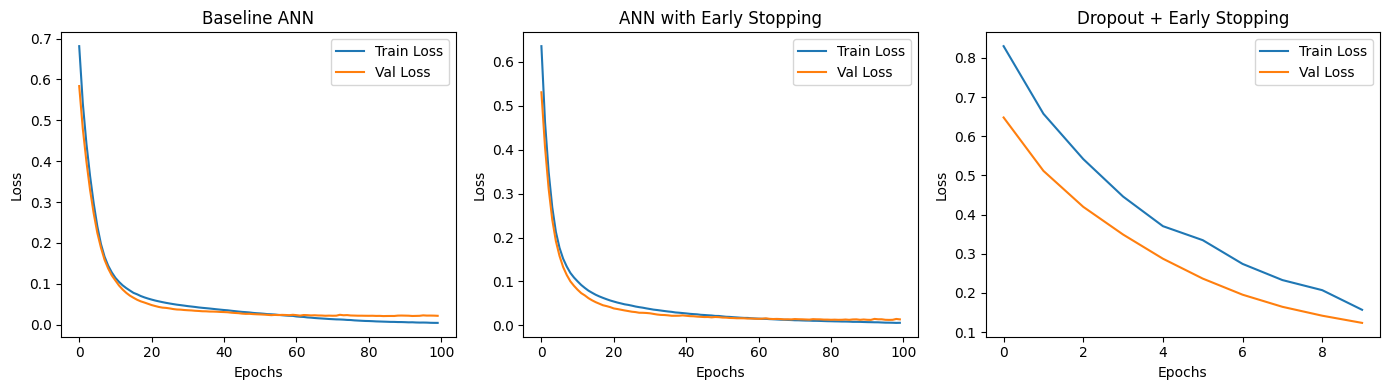

In [12]:

# 8. Plot training and validation loss
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Val Loss')
plt.title('Baseline ANN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_es.history['loss'], label='Train Loss')
plt.plot(history_es.history['val_loss'], label='Val Loss')
plt.title('ANN with Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_dropout.history['loss'], label='Train Loss')
plt.plot(history_dropout.history['val_loss'], label='Val Loss')
plt.title('Dropout + Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()



## Conclusion
- The **baseline ANN** may train for all epochs and can overfit.
- **Early Stopping** helps terminate training when validation performance stops improving.
- **Dropout + Early Stopping** usually gives better generalization and reduces overfitting.

## Viva Points
- **Early Stopping** prevents unnecessary training and restores best weights.
- **Dropout** randomly disables some neurons during training to reduce dependency on specific neurons.
- Breast cancer prediction is a **binary classification** problem, so we use:
  - `sigmoid` in the output layer
  - `binary_crossentropy` loss
